In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


%matplotlib inline

In [ ]:
df= kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arnabchaki/fitness-trackers-products-ecommerce",
    "smartwatches.csv"
)

In [ ]:
df

In [ ]:
df.drop_duplicates(inplace=True)
train_df=df.sample(frac=0.8,random_state=42)
train_df

In [ ]:
test_df=df.drop(train_df.index)

In [ ]:
test_df

In [ ]:
test_df=test_df.reset_index()
train_df=train_df.reset_index()

In [ ]:
train_df.head()

In [ ]:
train_df.info()

In [ ]:
train_df['Display Size'].isna().sum()

In [ ]:
train_df['Display Size'].value_counts().count()

In [ ]:
train_df.info()

In [ ]:
train_df.drop(['index','Unnamed: 0'],axis=1,inplace=True)

In [ ]:
train_df.head()

In [ ]:
train_df['Display Size'].value_counts()

In [ ]:
train_df['Display Size'].isna().sum()

In [ ]:
train_df['Display Size'] = train_df['Display Size'].fillna('11.0 inches')

In [ ]:
train_df['Display Size'].isna().sum()

In [ ]:
train_df['Display Size'] = train_df['Display Size'].apply(lambda x: float(x.split()[0]))

In [ ]:
train_df.head()

In [ ]:
train_df['Display Size'].replace(11.0,np.nan,inplace=True)

In [ ]:
train_df.head()

In [ ]:
train_df

In [ ]:
train_df['Weight'].value_counts()

In [ ]:
import re

In [ ]:
# \d → ['2', '0', '3', '5'] (each digit separately)
# \d+ → ['20', '35'] (grouped numbers)
re.findall('\d+','20 - 35 g')

In [ ]:
cal=sum([int(x) for x in re.findall('\d+','20 - 35 g')])//2

In [ ]:
print(cal)

In [ ]:
train_df['Weight']=train_df['Weight'].replace('20 - 35 g',cal)

In [ ]:
train_df.tail(10)

In [ ]:
train_df['Weight'].value_counts()

In [ ]:
cal=sum([int(x) for x in re.findall('\d+','35 - 50 g')])//2
# train_df['Weight']=train_df['Weight'].replace(x for x in re.findall('\d+'),sum([int(x) for x in re.findall('\d+','35 - 50 g')])//2)

In [ ]:
train_df['Weight'].value_counts()

In [ ]:
#this will change all the value in the weight column, instead of we repeating the steps.
train_df['Weight']=train_df['Weight'].apply(lambda x:sum(map(int,re.findall(r'\d+',str(x))))/len(re.findall(r'\d+',str(x))) if isinstance(x,str) and re.search(r'\d+',x) else x)

In [ ]:
train_df['Weight'].value_counts()

In [ ]:
train_df['Weight']=train_df['Weight'].replace(np.nan,0.0)

In [ ]:
train_df.dtypes

In [ ]:
train_df

In [ ]:
train_df['Discount Price']=((train_df['Original Price'] * -train_df['Discount Percentage'])/100).round(2)

In [ ]:
train_df['Discount Price'].replace(np.nan,0.0,inplace=True)

In [ ]:
train_df

In [ ]:
train_df.info()

In [ ]:
numerical_col=[feature for feature in train_df if train_df[feature].dtype=='float64']

In [ ]:
train_df[numerical_col].head()

In [ ]:
numerical_col

In [ ]:
fig,axes=plt.subplots(nrows=3,ncols=3,figsize=(20,15))
# print(fig)
# axes
for i,column in enumerate(numerical_col):
    row=i//3
    col=i%3
    ax=axes[row,col]
    sns.kdeplot(data=train_df[column],ax=ax,fill=True)
plt.show()

In [ ]:
fig,axes=plt.subplots(nrows=3,ncols=3,figsize=(14,10))
# print(fig)
# axes
for i,column in enumerate(numerical_col):
    row=i//3
    col=i%3
    ax=axes[row,col]
    sns.boxplot(data=train_df[column],ax=ax)
#     plt.xlabel(column)
    ax.set_xlabel(column)
plt.show()

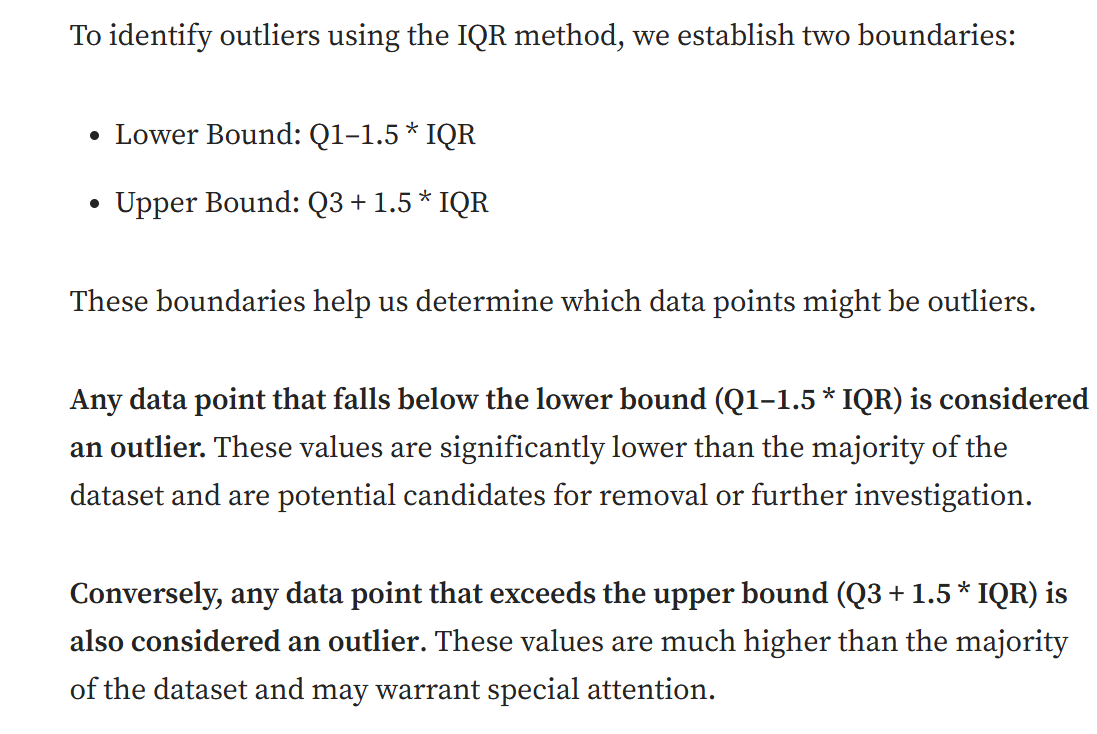

Imagine sorted data:

10, 20, 30, 40, 50
25th percentile ≈ 20

👉 Meaning:

25% of values are ≤ 20
75% of values are > 20

In [ ]:
def remove_outliers_IQR(data,col):
    Q1=data[col].quantile(0.25)
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1
    LB=Q1-1.5 * IQR
    UB=Q3+1.5 * IQR
    return data[(data[col]>LB) & (data[col]<UB)]

In [ ]:
train_df

In [ ]:
train_df.columns

In [ ]:
important_col=['Current Price','Original Price','Number OF Ratings','Rating','Display Size','Discount Price']

In [ ]:
for col in important_col:
    train_df=remove_outliers_IQR(train_df,col)

In [ ]:
train_df

In [ ]:
for col in numerical_col:
    train_df[col].fillna(train_df[col].median(),inplace=True)

In [ ]:
train_df

In [ ]:
train_df[numerical_col].isna().sum()

In [ ]:
train_df.isna().sum()

In [ ]:
train_df[numerical_col].head()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scale=MinMaxScaler()

In [ ]:
scaled_data=scale.fit_transform(train_df[numerical_col[:-1]])

In [ ]:
scaled_data

In [ ]:
data=pd.DataFrame(scaled_data,columns=numerical_col[:-1])

In [ ]:
data.head()

In [ ]:
data

In [ ]:
data.shape, train_df.shape

In [ ]:
train_df

In [ ]:
train_df.drop(numerical_col[:-1],axis=1,inplace=True)

In [ ]:
train_df

In [ ]:
pd.concat([train_df.reset_index(),data],axis=1).shape

In [ ]:
train_df=pd.concat([train_df.reset_index(), data], axis=1)

In [ ]:
train_df.head()

In [ ]:
train_df[numerical_col]

In [ ]:
categorical_col=[feature for feature in train_df.columns if train_df[feature].dtype == 'object']

In [ ]:
categorical_col

In [ ]:
train_df.dtypes

In [ ]:
train_df[categorical_col].head()

Great—these are the **core outputs of ANOVA**. Let’s make them very clear 👇

---

## 🔹 1. F-statistic (F-value)

👉 This measures:

> **How different the group means are compared to variation inside groups**

---

### 🧠 Formula idea (don’t memorize, just understand)

[
F = \frac{\text{variance between groups}}{\text{variance within groups}}
]

---

### 🔍 Intuition

* **Between-group variance** → difference between group means
* **Within-group variance** → spread inside each group

---

### 🔥 Interpretation

| F value | Meaning                     |
| ------- | --------------------------- |
| Small   | Groups are similar ❌        |
| Large   | Groups are very different ✅ |

---

### 🧠 Simple idea

👉

> “Are group differences big enough compared to noise?”

---

## 🔹 2. p-value

👉 This tells you:

> **How likely it is that the observed difference happened by chance**

---

### 🔥 Interpretation

| p-value | Meaning                     |
| ------- | --------------------------- |
| < 0.05  | Significant difference ✅    |
| > 0.05  | No significant difference ❌ |

---

### 🧠 Simple idea

👉

> “Can I trust this difference, or is it just random?”

---

## 🔗 How they work together

* **F-value** → measures the difference
* **p-value** → tells if that difference is statistically meaningful

---

## 🔍 Example

```text
F = 25
p = 0.001
```

👉 Meaning:

* Large F → big difference
* Small p → not by chance

✅ Conclusion:

> Groups are significantly different

---

## ❌ Another case

```text
F = 1.2
p = 0.3
```

👉 Meaning:

* Small F → small difference
* Large p → could be random

❌ Conclusion:

> No significant difference

---

## 🔥 Final intuition

* **F-value** = “How big is the difference?”
* **p-value** = “Is the difference real?”

---

## ⚡ One-line memory trick

👉

> “F finds the difference, p tells if it matters”

---

If you want, I can show you **how these values are actually computed step-by-step with numbers** (super helpful for deep understanding) 👍


In [ ]:
#because it is having only one value but for doing this anova test we need 2 values atleast
categorical_col.remove('Bluetooth') 

In [ ]:
categorical_col

In [ ]:
train_df['Bluetooth'].value_counts()

In [ ]:
from scipy.stats import f_oneway

Nice—you’re actually very close to a **correct ANOVA pipeline** 👏
Let me explain exactly what your code is doing step by step.

---

## 🔹 Your code

```python
for col in categorical_col:
    CategoryGroup = train_df.groupby(col)['Discount Price'].apply(list)
    AnovaResults = f_oneway(*CategoryGroup)
    print(AnovaResults)
```

---

## 🔍 Step-by-step explanation

### 1️⃣ Loop over categorical columns

```python
for col in categorical_col:
```

👉 You are checking:

> “Does each categorical column affect Discount Price?”

---

### 2️⃣ Group + convert to list

```python
CategoryGroup = train_df.groupby(col)['Discount Price'].apply(list)
```

👉 This creates something like:

```text
Brand:
A → [100, 120, 130]
B → [200, 210, 220]
C → [150, 160]
```

So internally:

```python
CategoryGroup = [
    [100,120,130],
    [200,210,220],
    [150,160]
]
```

---

### 3️⃣ `*CategoryGroup` (VERY IMPORTANT)

```python
f_oneway(*CategoryGroup)
```

👉 The `*` unpacks the lists:

Instead of:

```python
f_oneway(CategoryGroup)
```

It becomes:

```python
f_oneway([100,120,130], [200,210,220], [150,160])
```

👉 This is exactly what ANOVA needs ✅

---

### 4️⃣ Output

```python
AnovaResults
```

Gives:

```text
F-statistic, p-value
```

Example:

```text
F = 15.2, p = 0.0001
```

---

## 🧠 What your entire loop is doing

👉 For each categorical column:

1. Split Discount Price into groups
2. Compare their means
3. Check if difference is significant

---

## 🔥 What you should interpret

Modify print like this:

```python
for col in categorical_col:
    CategoryGroup = train_df.groupby(col)['Discount Price'].apply(list)
    AnovaResults = f_oneway(*CategoryGroup)
    
    print(f"{col} → p-value: {AnovaResults.pvalue}")
```

---

## ✅ Decision rule

```python
if p < 0.05:
    print("Important feature ✅")
else:
    print("Not important ❌")
```

---

## ⚠️ Important improvement

ANOVA fails if:

* Any group has **very few values**
* Missing values exist

So better:

```python
CategoryGroup = train_df.groupby(col)['Discount Price'].apply(list)

# Remove empty/small groups
CategoryGroup = [group for group in CategoryGroup if len(group) > 1]
```

---

## 🔥 Final intuition

👉 Your code is basically doing:

> “For each categorical feature, check if it actually influences Discount Price”

---

## ⚡ One-line summary

> You are converting categories into groups and feeding them into ANOVA to test significance

---

If you want, I can show you how to **automatically select only important features from this loop** (very useful for ML) 👍


In [ ]:
important_cat_col=[]
for col in categorical_col:
    CategoryGroup = train_df.groupby(col)['Discount Price'].apply(list)
    AnovaResults=f_oneway(*CategoryGroup)
    print(col,': F-Value--> ',AnovaResults[0],'p-value-->',AnovaResults[1])
    if AnovaResults.pvalue < 0.055:
        important_cat_col.append(col)
        
print(important_cat_col)

In [ ]:
for col in important_cat_col:
    train_df[col].fillna('other',inplace=True)

In [ ]:
train_df[important_cat_col]

In [ ]:
train_df[important_cat_col].isna().sum()

## GET DUMMIES
Here’s a **simple, clear example with just one column** 👇

---

## 🔹 Original column

```python
import pandas as pd

df = pd.DataFrame({
    'Brand': ['Apple', 'Samsung', 'Noise', 'Apple']
})

print(df)
```

### Output:

```text
     Brand
0    Apple
1  Samsung
2    Noise
3    Apple
```

---

## 🔹 Apply `get_dummies()`

```python
pd.get_dummies(df['Brand'])
```

---

## 🔥 Result

```text
   Apple  Noise  Samsung
0      1      0        0
1      0      0        1
2      0      1        0
3      1      0        0
```

---

## 🧠 What happened?

* Each **unique value** becomes a new column
* Value present → `1`
* Value absent → `0`

---

## 🔹 Replace original column in DataFrame

```python
df = pd.get_dummies(df, columns=['Brand'])
```

---

### Final DataFrame:

```text
   Brand_Apple  Brand_Noise  Brand_Samsung
0            1            0              0
1            0            0              1
2            0            1              0
3            1            0              0
```

---

## ⚡ One-line intuition

👉

> “One column → multiple binary columns (0 or 1)”

---

If you want, I can show you this on your **actual dataset columns (like Brand, Category)** 👍


In [ ]:
pd.get_dummies(train_df['Original Price']).astype(int)

In [ ]:
train_df['Original Price'].value_counts()

In [ ]:
brand=pd.get_dummies(train_df['Brand']).drop('other',errors='ignore',axis=1).astype(int)

In [ ]:
important_cat_col

In [ ]:
model_name=pd.get_dummies(train_df['Model Name']).drop('other',axis=1).astype(int)
Dial_shape=pd.get_dummies(train_df['Dial Shape']).drop('other',axis=1).astype(int)
Strap_material=pd.get_dummies(train_df['Strap Material']).drop('other',axis=1).astype(int)

In [ ]:
imp_df=pd.concat([brand, model_name,Dial_shape,Strap_material],axis=1)
imp_df

In [ ]:
new_df=pd.concat([train_df[numerical_col],imp_df],axis=1)

In [ ]:
new_df

In [ ]:
new_df.isna().sum()

In [ ]:
 new_df.reset_index()

In [ ]:
new_df.to_csv('clean_data.csv', index=False)